<a href="https://colab.research.google.com/github/Joseph-Scripture/student-performance/blob/main/students_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("larsen0966/student-performance-data-set")

print("Path to dataset files:", path)
os.listdir(path)

Using Colab cache for faster access to the 'student-performance-data-set' dataset.
Path to dataset files: /kaggle/input/student-performance-data-set


['student-por.csv']

In [ ]:
df = pd.read_csv(os.path.join(path, 'student-por.csv'))
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
X = df.drop('G3', axis=1)
y = df['G3']

In [ ]:
def grade_category(grade):
    if grade < 10:
        return 0
    elif grade < 15:
        return 1
    elif grade < 18:
        return 2
    else:
        return 3

y = df["G3"].apply(grade_category)
y.unique()

array([1, 2, 0, 3])

In [ ]:
# Encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

# Fit scaler only on training data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_encoded.shape

(649, 41)

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

In [ ]:
import torch.nn as nn

class ModelEmpty(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.layers(x)

In [ ]:
model = ModelEmpty(
    input_dim=X_train.shape[1],
    hidden_dim=64,
    output_dim=4
)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.05
)
epochs = 100
without_reg_losses = []
without_reg_test_losses = []
without_reg_train_accuracies = []
without_reg_test_accuracies = []


In [ ]:

for epoch in range(epochs):

    model.train()

    logits = model(X_train)

    loss = criterion(logits, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    without_reg_losses.append(loss.item())

    preds = torch.argmax(logits, dim=1)

    acc = (preds == y_train).float().mean()
    without_reg_train_accuracies.append(acc.item())

# Evaluating on test set
    model.eval()

    with torch.no_grad():
        logits = model(X_test)
        preds = torch.argmax(logits, dim=1)
        test_loss = criterion(logits, y_test)
        without_reg_test_losses.append(test_loss.item())

        test_acc = (preds == y_test).float().mean()
        without_reg_test_accuracies.append(test_acc.item())

# print(f"Test Accuracy: {test_acc:.4f}")

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch}: "
            f"Training Loss={loss.item():.4f} "
            f"Training Accuracy={acc:.4f} "
            f"Test Loss={test_loss.item():.4f} "
            f"Test Accuracy={test_acc:.4f} "
        )

Epoch 0: Training Loss=1.4279 Training Accuracy=0.1618 Test Loss=1.3868 Test Accuracy=0.2923 
Epoch 10: Training Loss=1.0829 Training Accuracy=0.6455 Test Loss=1.0970 Test Accuracy=0.6308 
Epoch 20: Training Loss=0.9667 Training Accuracy=0.6455 Test Loss=1.0075 Test Accuracy=0.6385 
Epoch 30: Training Loss=0.9040 Training Accuracy=0.6455 Test Loss=0.9634 Test Accuracy=0.6385 
Epoch 40: Training Loss=0.8554 Training Accuracy=0.6455 Test Loss=0.9310 Test Accuracy=0.6385 
Epoch 50: Training Loss=0.8123 Training Accuracy=0.6474 Test Loss=0.9028 Test Accuracy=0.6385 
Epoch 60: Training Loss=0.7729 Training Accuracy=0.6590 Test Loss=0.8769 Test Accuracy=0.6538 
Epoch 70: Training Loss=0.7368 Training Accuracy=0.6763 Test Loss=0.8532 Test Accuracy=0.6692 
Epoch 80: Training Loss=0.7037 Training Accuracy=0.7110 Test Loss=0.8314 Test Accuracy=0.6846 
Epoch 90: Training Loss=0.6738 Training Accuracy=0.7360 Test Loss=0.8118 Test Accuracy=0.6923 


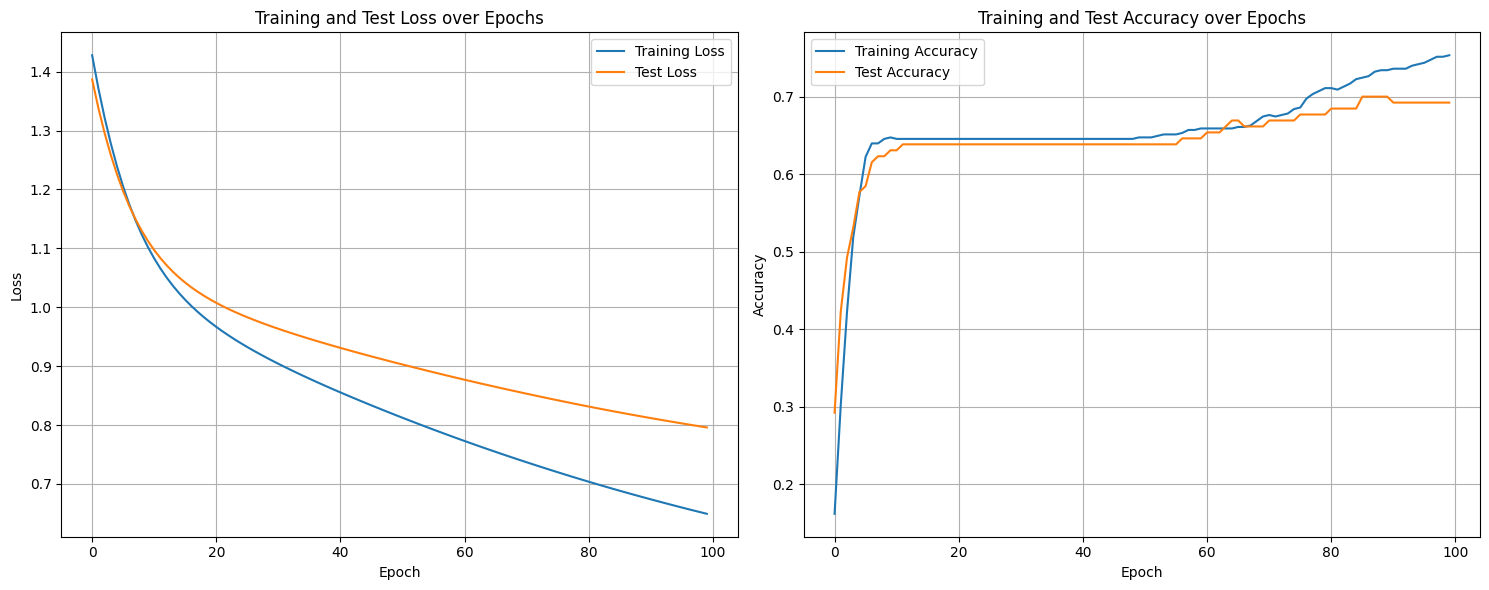

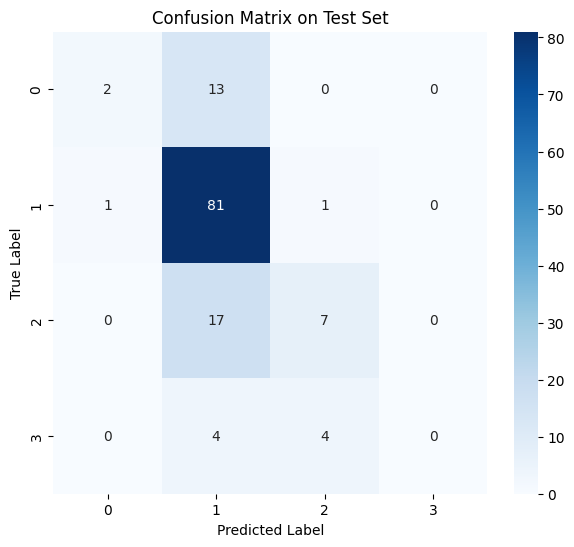

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Create a figure with two subplots for loss and accuracy
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # First subplot for Loss
plt.plot(range(len(without_reg_losses)), without_reg_losses, label='Training Loss')
plt.plot(range(len(without_reg_test_losses)), without_reg_test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2) # Second subplot for Accuracy
plt.plot(range(len(without_reg_train_accuracies)), without_reg_train_accuracies, label='Training Accuracy')
plt.plot(range(len(without_reg_test_accuracies)), without_reg_test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

# Confusion Matrix
plt.figure(figsize=(7, 6))
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_preds = torch.argmax(test_logits, dim=1)

# Convert tensors to numpy arrays for sklearn's confusion_matrix
cm = confusion_matrix(y_test.cpu().numpy(), test_preds.cpu().numpy())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()

In [ ]:
class ModelDropOut(nn.Module):
  def __init__(self, input_dim, hidden_dim, output_dim):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(hidden_dim, output_dim)
    )
  def forward(self, x):
    return self.layers(x)

In [ ]:
model = ModelDropOut(
    input_dim = X_train.shape[1],
    hidden_dim = 64,
    output_dim = 4
)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.05
)
dropout_train_losses = []
dropout_train_acc = []
dropout_test_losses = []
dropout_test_acc = []
epochs = 100

In [ ]:
for epoch in range(epochs):
  model.train()
  train_logits = model(X_train)
  train_loss = criterion(train_logits, y_train)
  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()
  dropout_train_losses.append(train_loss.item())
  train_preds = torch.argmax(train_logits, dim=1)
  train_acc = (train_preds == y_train).float().mean()
  dropout_train_acc.append(train_acc.item())
  # test section

  with torch.no_grad():
    model.eval()
    test_logits = model(X_test)
    test_loss = criterion(test_logits, y_test)
    dropout_test_losses.append(test_loss.item())
    test_preds = torch.argmax(test_logits, dim=1)
    test_acc = (test_preds == y_test).float().mean()
    dropout_test_acc.append(test_acc.item())
  if epoch % 10 == 0:
    print(
        f"Epoch {epoch}: "
        f"Training Loss={train_loss.item():.4f} "
        f"Training Accuracy={train_acc.item():.4f} "
        f"Test Loss={test_loss.item():.4f} "
        f"Test Accuracy={test_acc.item():.4f} "
    )

Epoch 0: Training Loss=1.4823 Training Accuracy=0.1349 Test Loss=1.4007 Test Accuracy=0.2538 
Epoch 10: Training Loss=1.1074 Training Accuracy=0.6493 Test Loss=1.0881 Test Accuracy=0.6462 
Epoch 20: Training Loss=0.9782 Training Accuracy=0.6455 Test Loss=0.9916 Test Accuracy=0.6385 
Epoch 30: Training Loss=0.9087 Training Accuracy=0.6474 Test Loss=0.9459 Test Accuracy=0.6385 
Epoch 40: Training Loss=0.8609 Training Accuracy=0.6455 Test Loss=0.9125 Test Accuracy=0.6385 
Epoch 50: Training Loss=0.8182 Training Accuracy=0.6551 Test Loss=0.8840 Test Accuracy=0.6462 
Epoch 60: Training Loss=0.7751 Training Accuracy=0.6744 Test Loss=0.8589 Test Accuracy=0.6462 
Epoch 70: Training Loss=0.7331 Training Accuracy=0.7071 Test Loss=0.8367 Test Accuracy=0.6692 
Epoch 80: Training Loss=0.7056 Training Accuracy=0.7360 Test Loss=0.8177 Test Accuracy=0.7000 
Epoch 90: Training Loss=0.6698 Training Accuracy=0.7514 Test Loss=0.8007 Test Accuracy=0.6923 


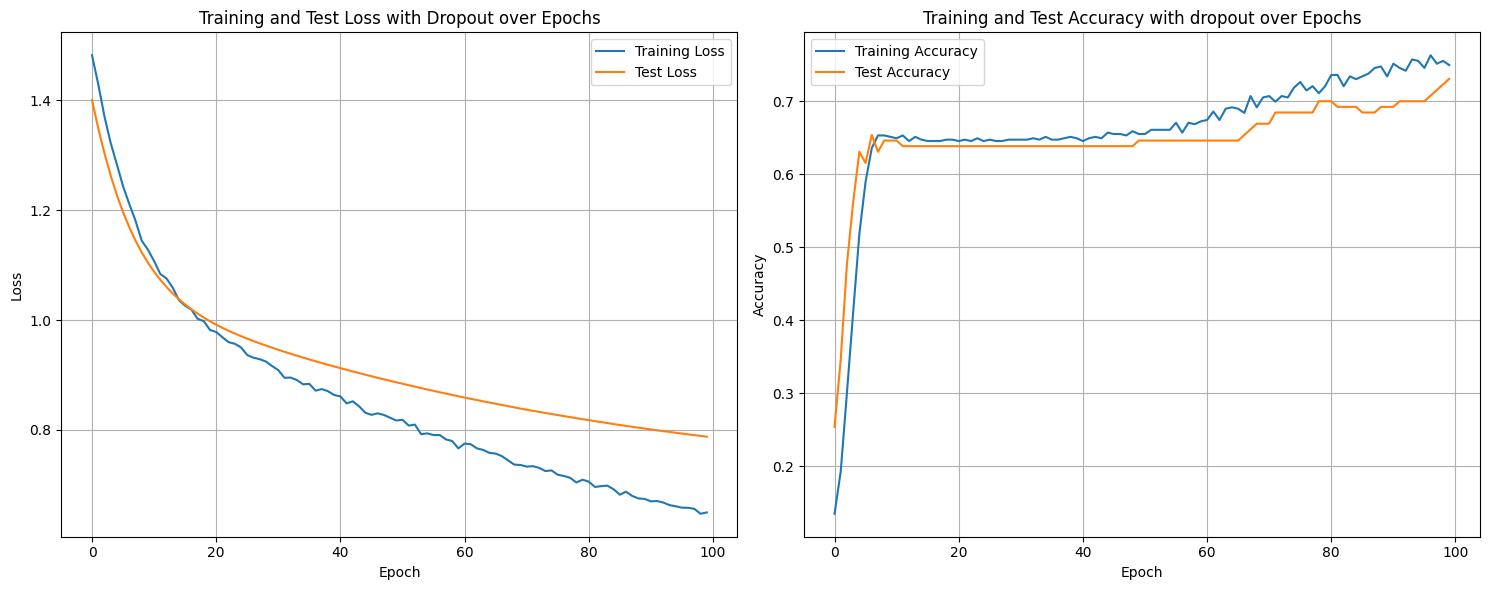

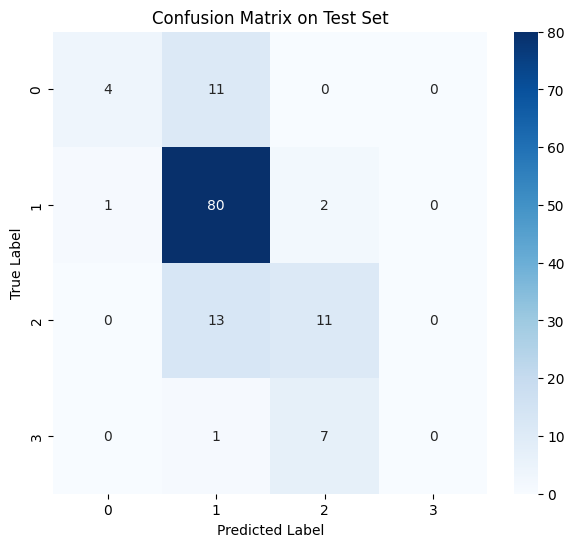

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Create a figure with two subplots for loss and accuracy
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # First subplot for Loss
plt.plot(range(len(dropout_train_losses)), dropout_train_losses, label='Training Loss')
plt.plot(range(len(dropout_test_losses)), dropout_test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss with Dropout over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2) # Second subplot for Accuracy
plt.plot(range(len(dropout_train_acc)), dropout_train_acc, label='Training Accuracy')
plt.plot(range(len(dropout_test_acc)), dropout_test_acc, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy with dropout over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

# Confusion Matrix
plt.figure(figsize=(7, 6))
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_preds = torch.argmax(test_logits, dim=1)

# Convert tensors to numpy arrays for sklearn's confusion_matrix
cm = confusion_matrix(y_test.cpu().numpy(), test_preds.cpu().numpy())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()

In [ ]:
class WeightDecay(nn.Module):
  def __init__(self, input_dim, hidden_dim, output_dim):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, output_dim),
    )
  def forward(self, x):
    return self.layers(x)

In [ ]:
model = WeightDecay(
    input_dim = X_train.shape[1],
    hidden_dim = 64,
    output_dim = 4
)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.05, weight_decay=0.001)
epochs = 100
wd_train_losses = []
wd_train_acc = []
wd_test_losses = []
wd_test_acc = []
#

In [ ]:
for epoch in range(epochs):
  model.train()
  train_logits = model(X_train)
  train_loss = criterion(train_logits, y_train)
  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()
  wd_train_losses.append(train_loss.item())
  train_preds = torch.argmax(train_logits, dim=1)
  train_acc = (train_preds == y_train).float().mean()
  wd_train_acc.append(train_acc.item())
  # test section

  with torch.no_grad():
    model.eval()
    test_logits = model(X_test)
    test_loss = criterion(test_logits, y_test)
    wd_test_losses.append(test_loss.item())
    test_preds = torch.argmax(test_logits, dim=1)
    test_acc = (test_preds == y_test).float().mean()
    wd_test_acc.append(test_acc.item())
  if epoch % 10 == 0:
    print(
        f"Epoch {epoch}: "
        f"Training Loss={train_loss.item():.4f} "
        f"Training Accuracy={train_acc.item():.4f} "
        f"Test Loss={test_loss.item():.4f} "
        f"Test Accuracy={test_acc.item():.4f} "
    )

Epoch 0: Training Loss=1.4453 Training Accuracy=0.1811 Test Loss=1.4093 Test Accuracy=0.2231 
Epoch 10: Training Loss=1.0660 Training Accuracy=0.6435 Test Loss=1.0944 Test Accuracy=0.6538 
Epoch 20: Training Loss=0.9486 Training Accuracy=0.6455 Test Loss=1.0131 Test Accuracy=0.6385 
Epoch 30: Training Loss=0.8873 Training Accuracy=0.6455 Test Loss=0.9764 Test Accuracy=0.6385 
Epoch 40: Training Loss=0.8397 Training Accuracy=0.6493 Test Loss=0.9486 Test Accuracy=0.6462 
Epoch 50: Training Loss=0.7972 Training Accuracy=0.6590 Test Loss=0.9238 Test Accuracy=0.6538 
Epoch 60: Training Loss=0.7583 Training Accuracy=0.6667 Test Loss=0.9009 Test Accuracy=0.6538 
Epoch 70: Training Loss=0.7227 Training Accuracy=0.6936 Test Loss=0.8800 Test Accuracy=0.6692 
Epoch 80: Training Loss=0.6904 Training Accuracy=0.7264 Test Loss=0.8611 Test Accuracy=0.6769 
Epoch 90: Training Loss=0.6611 Training Accuracy=0.7553 Test Loss=0.8441 Test Accuracy=0.6846 


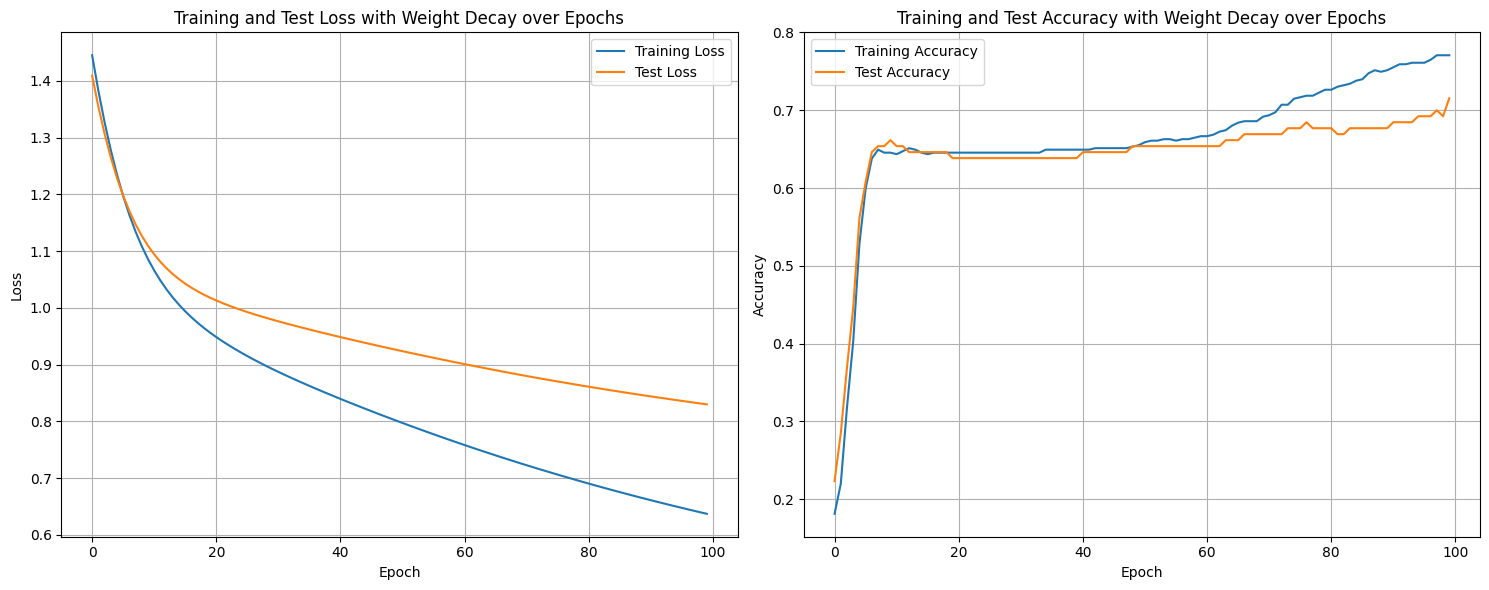

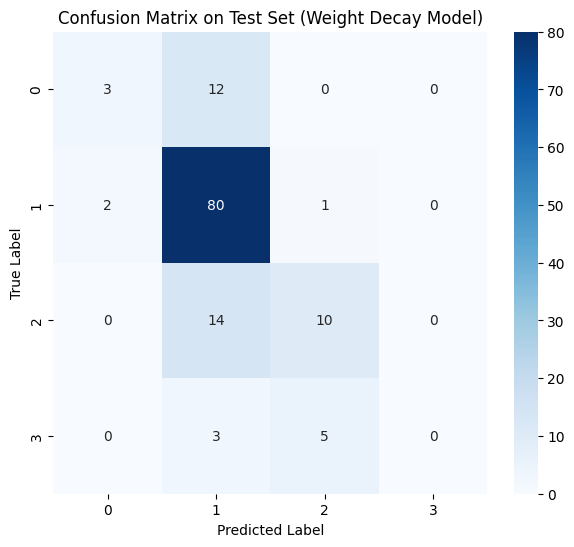

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Create a figure with two subplots for loss and accuracy
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # First subplot for Loss
plt.plot(range(len(wd_train_losses)), wd_train_losses, label='Training Loss')
plt.plot(range(len(wd_test_losses)), wd_test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss with Weight Decay over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2) # Second subplot for Accuracy
plt.plot(range(len(wd_train_acc)), wd_train_acc, label='Training Accuracy')
plt.plot(range(len(wd_test_acc)), wd_test_acc, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy with Weight Decay over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

# Confusion Matrix
plt.figure(figsize=(7, 6))
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_preds = torch.argmax(test_logits, dim=1)

# Convert tensors to numpy arrays for sklearn's confusion_matrix
cm = confusion_matrix(y_test.cpu().numpy(), test_preds.cpu().numpy())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set (Weight Decay Model)')
plt.show()

In [215]:
class Combined(nn.Module):
  def __init__(self, input_dim, hidden_dim, output_dim):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(hidden_dim, output_dim)
    )
  def forward(self, x):
    return self.layers(x)

In [220]:
model = Combined(
    input_dim = X_train.shape[1],
    hidden_dim = 64,
    output_dim = 4
)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.05,
    weight_decay=2e-4
)
epochs = 100
combined_training_loss = []
combined_training_acc = []
combined_test_loss = []
combined_test_acc = []

In [225]:
for epoch in range(epochs):
  model.train()
  train_logits = model(X_train)
  train_loss = criterion(train_logits, y_train)
  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()
  combined_training_loss.append(train_loss.item())
  train_preds = torch.argmax(train_logits, dim=1)
  train_acc = (train_preds == y_train).float().mean()
  combined_training_acc.append(train_acc.item())
  # Evaluation
  with torch.no_grad():
    model.eval()
    test_logits = model(X_test)
    test_loss = criterion(test_logits, y_test)
    combined_test_loss.append(test_loss.item())
    test_preds = torch.argmax(test_logits, dim=1)
    test_acc = (test_preds == y_test).float().mean()
    combined_test_acc.append(test_acc.item())
  if (epoch + 1) % 10 == 0:
    print(f"Epoch {epoch + 1}: {train_loss.item():.4f} Train acc: {train_acc.item():.4f} "
          f"TEST Loss: {test_loss.item():.4f} "  f" TEST Acc: {test_acc.item():.4f}")

Epoch 10: 0.4415 Train acc: 0.8208 TEST Loss: 0.7237  TEST Acc: 0.7615
Epoch 20: 0.4157 Train acc: 0.8478 TEST Loss: 0.7172  TEST Acc: 0.7538
Epoch 30: 0.4100 Train acc: 0.8459 TEST Loss: 0.7113  TEST Acc: 0.7538
Epoch 40: 0.3922 Train acc: 0.8863 TEST Loss: 0.7053  TEST Acc: 0.7538
Epoch 50: 0.4058 Train acc: 0.8536 TEST Loss: 0.6997  TEST Acc: 0.7538
Epoch 60: 0.3767 Train acc: 0.8651 TEST Loss: 0.6941  TEST Acc: 0.7462
Epoch 70: 0.3834 Train acc: 0.8613 TEST Loss: 0.6887  TEST Acc: 0.7538
Epoch 80: 0.3654 Train acc: 0.8748 TEST Loss: 0.6832  TEST Acc: 0.7538
Epoch 90: 0.3774 Train acc: 0.8671 TEST Loss: 0.6772  TEST Acc: 0.7538
Epoch 100: 0.3685 Train acc: 0.8574 TEST Loss: 0.6715  TEST Acc: 0.7769


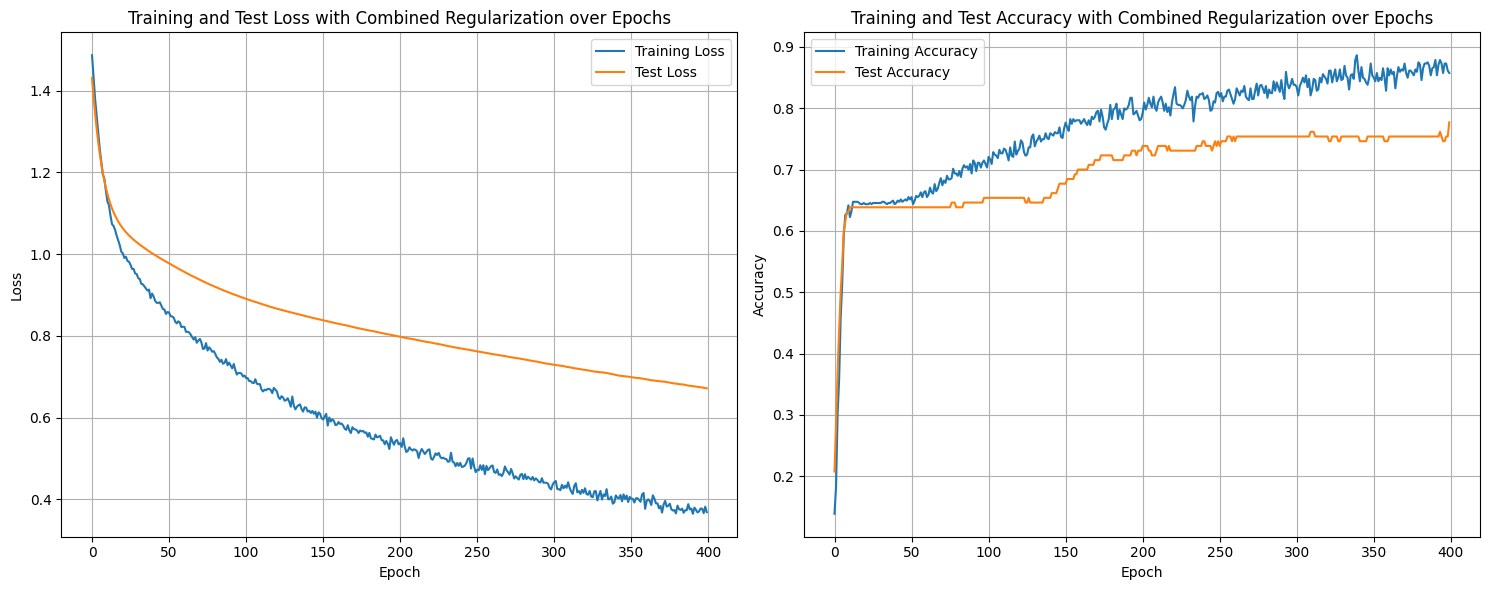

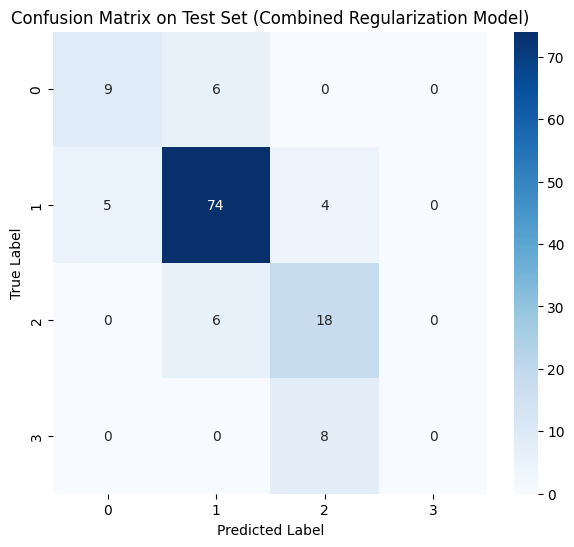

In [226]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Create a figure with two subplots for loss and accuracy
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # First subplot for Loss
plt.plot(range(len(combined_training_loss)), combined_training_loss, label='Training Loss')
plt.plot(range(len(combined_test_loss)), combined_test_loss, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss with Combined Regularization over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2) # Second subplot for Accuracy
plt.plot(range(len(combined_training_acc)), combined_training_acc, label='Training Accuracy')
plt.plot(range(len(combined_test_acc)), combined_test_acc, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy with Combined Regularization over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

# Confusion Matrix
plt.figure(figsize=(7, 6))
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_preds = torch.argmax(test_logits, dim=1)

# Convert tensors to numpy arrays for sklearn's confusion_matrix
cm = confusion_matrix(y_test.cpu().numpy(), test_preds.cpu().numpy())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set (Combined Regularization Model)')
plt.show()

In [227]:
print(f"Final loss without regularization: {without_reg_test_losses[-1]}")
print(f"Final accuracy without regularization: {without_reg_test_accuracies[-1]}")
print(f"Final loss with dropout: {dropout_test_losses[-1]}")
print(f"Final accuracy with dropout: {dropout_test_acc[-1]}")
print(f"Final loss with weight decay: {wd_test_losses[-1]}")
print(f"Final accuracy with weight decay: {wd_test_acc[-1]}")
print(f"Final loss with combined regularization: {combined_test_loss[-1]}")
print(f"Final accuracy with combined regularization: {combined_test_acc[-1]}")

Final loss without regularization: 0.7959398031234741
Final accuracy without regularization: 0.692307710647583
Final loss with dropout: 0.7875632643699646
Final accuracy with dropout: 0.7307692170143127
Final loss with weight decay: 0.8300690650939941
Final accuracy with weight decay: 0.7153846025466919
Final loss with combined regularization: 0.6715483665466309
Final accuracy with combined regularization: 0.7769230604171753
